# Deep CFR: Encoding And Replay Schedules

Two controlled experiments:

1. Compare infoset encodings across an easy, current, and structurally different spec.
2. Compare fixed and adaptive advantage-fitting schedules using the selected encoding.

The established choices are held fixed unless explicitly varied: positive-weighted MSE with `beta=0.5`, a `256x256` MLP, alternating updates, and `strategy_train_steps=50`. Exact evaluation and exact generated-strategy averaging are used while these specs remain tractable.

In [1]:
import gc
import math
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'liars_poker').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from liars_poker.algo.deep_cfr import DeepCFRTrainer, ReservoirBuffer
from liars_poker.algo.deep_cfr_diagnostics import ExactDenseStrategyAverager
from liars_poker.core import GameSpec, possible_starting_hands
from liars_poker.env import rules_for_spec
from liars_poker.infoset import CALL
from liars_poker.policies.neural import InfosetEncoder, NeuralMLP, NeuralPolicy
from liars_poker.training.deep_cfr import deep_cfr_timed_loop


## Shared experimental trainer

This notebook-local trainer supports a supplied encoder, positive-weighted advantage MSE, and several advantage-fitting schedules. Rebuilding the networks immediately after `DeepCFRTrainer` initialization keeps the production implementation untouched.

In [2]:
class StructuredInfosetEncoder(InfosetEncoder):
    """Baseline features plus explicit last claim, depth, and legal-action mask."""

    def __init__(self, spec):
        super().__init__(spec)
        self.base_encoder = InfosetEncoder(spec)
        self.base_input_dim = self.input_dim
        self.input_dim = self.base_input_dim + self.k + 1 + self.action_dim

    @staticmethod
    def _action_col(action):
        return 0 if action == CALL else action + 1

    def _public_features(self, history):
        last = history[-1] if history else None
        last_claim = np.zeros(self.k, dtype=np.float32)
        if last is not None:
            last_claim[last] = 1.0
        depth = np.asarray([len(history)], dtype=np.float32)
        legal_mask = np.zeros(self.action_dim, dtype=np.float32)
        for action in self.rules.legal_actions_from_last(last):
            legal_mask[self._action_col(action)] = 1.0
        return np.concatenate((last_claim, depth, legal_mask))

    def encode(self, hand, history):
        return np.concatenate((self.base_encoder.encode(hand, history), self._public_features(history)))

    def encode_hands(self, hands, history):
        base = self.base_encoder.encode_hands(hands, history)
        public = np.repeat(self._public_features(history)[None, :], len(hands), axis=0)
        return np.concatenate((base, public), axis=1)


class SemanticInfosetEncoder(StructuredInfosetEncoder):
    """Structured features plus explicit claim kind and up to two claim ranks."""

    def __init__(self, spec):
        super().__init__(spec)
        self.structured_input_dim = self.input_dim
        self.input_dim = self.structured_input_dim + len(spec.claim_kinds) + 2 * spec.ranks

    def _semantic_features(self, history):
        kind_features = np.zeros(len(self.spec.claim_kinds), dtype=np.float32)
        rank_features = np.zeros(2 * self.spec.ranks, dtype=np.float32)
        if not history:
            return np.concatenate((kind_features, rank_features))

        kind, value = self.rules.claims[history[-1]]
        kind_features[self.spec.claim_kinds.index(kind)] = 1.0
        if kind == 'TwoPair':
            low, high = self.rules.two_pair_ranks[value]
            ranks = (high, low)
        elif kind == 'FullHouse':
            ranks = self.rules.full_house_ranks[value]
        else:
            ranks = (value,)
        for slot, rank in enumerate(ranks[:2]):
            rank_features[slot * self.spec.ranks + rank - 1] = 1.0
        return np.concatenate((kind_features, rank_features))

    def encode(self, hand, history):
        return np.concatenate((super().encode(hand, history), self._semantic_features(history)))

    def encode_hands(self, hands, history):
        base = super().encode_hands(hands, history)
        semantic = np.repeat(self._semantic_features(history)[None, :], len(hands), axis=0)
        return np.concatenate((base, semantic), axis=1)


ENCODERS = {
    'baseline': InfosetEncoder,
    'structured': StructuredInfosetEncoder,
    'semantic': SemanticInfosetEncoder,
}


In [3]:
class EncodedNeuralPolicy(NeuralPolicy):
    """Notebook-local playable policy using the experiment's encoder."""

    def __init__(self, spec, *, encoder_cls, hidden_sizes, device):
        super().__init__(spec, hidden_sizes=hidden_sizes, device=device)
        self.encoder = encoder_cls(spec)
        self.model_p1 = NeuralMLP(self.encoder.input_dim, self.encoder.action_dim, self.hidden_sizes).to(self.device)
        self.model_p2 = NeuralMLP(self.encoder.input_dim, self.encoder.action_dim, self.hidden_sizes).to(self.device)
        self.eval()


class ExperimentalDeepCFRTrainer(DeepCFRTrainer):
    """Deep CFR experiment harness with configurable encoding and replay schedule."""

    def __init__(
        self,
        spec,
        *,
        encoder_cls=InfosetEncoder,
        positive_beta=0.5,
        replay_mode='fixed_steps',
        replay_ratio=20.0,
        growing_ratio_start=10.0,
        growing_ratio_increment=0.15,
        growing_ratio_max=40.0,
        min_advantage_steps=25,
        max_advantage_steps=800,
        adaptive_chunk_steps=25,
        adaptive_min_steps=50,
        adaptive_max_steps=500,
        adaptive_patience=2,
        adaptive_min_relative_improvement=0.01,
        **kwargs,
    ):
        super().__init__(spec, **kwargs)
        self.positive_beta = float(positive_beta)
        self.replay_mode = replay_mode
        self.replay_ratio = float(replay_ratio)
        self.growing_ratio_start = float(growing_ratio_start)
        self.growing_ratio_increment = float(growing_ratio_increment)
        self.growing_ratio_max = float(growing_ratio_max)
        self.min_advantage_steps = int(min_advantage_steps)
        self.max_advantage_steps = int(max_advantage_steps)
        self.adaptive_chunk_steps = int(adaptive_chunk_steps)
        self.adaptive_min_steps = int(adaptive_min_steps)
        self.adaptive_max_steps = int(adaptive_max_steps)
        self.adaptive_patience = int(adaptive_patience)
        self.adaptive_min_relative_improvement = float(adaptive_min_relative_improvement)
        self._install_encoder(encoder_cls(spec))
        self._last_advantage_seen_for_fit = [0, 0]
        self._advantage_steps_used = [0, 0]
        self._new_advantage_records_for_fit = [0, 0]

    def _install_encoder(self, encoder):
        advantage_capacity = self.advantage_buffers[0].capacity
        strategy_capacity = self.strategy_buffers[0].capacity
        validation_capacity = self.advantage_validation_buffers[0].capacity
        self.encoder = encoder
        torch.manual_seed(self.seed)
        self.advantage_nets = [
            NeuralMLP(self.encoder.input_dim, self.encoder.action_dim, self.hidden_sizes).to(self.device)
            for _ in range(2)
        ]
        self.strategy_nets = [
            NeuralMLP(self.encoder.input_dim, self.encoder.action_dim, self.hidden_sizes).to(self.device)
            for _ in range(2)
        ]
        self.advantage_optimizers = [
            torch.optim.Adam(model.parameters(), lr=self.learning_rate)
            for model in self.advantage_nets
        ]
        self.strategy_optimizers = [
            torch.optim.Adam(model.parameters(), lr=self.learning_rate)
            for model in self.strategy_nets
        ]
        self.advantage_buffers = [
            ReservoirBuffer(advantage_capacity, self.encoder.input_dim, self.encoder.action_dim)
            for _ in range(2)
        ]
        self.strategy_buffers = [
            ReservoirBuffer(strategy_capacity, self.encoder.input_dim, self.encoder.action_dim)
            for _ in range(2)
        ]
        self.advantage_validation_buffers = [
            ReservoirBuffer(validation_capacity, self.encoder.input_dim, self.encoder.action_dim)
            for _ in range(2)
        ]
        self.strategy_validation_buffers = [
            ReservoirBuffer(validation_capacity, self.encoder.input_dim, self.encoder.action_dim)
            for _ in range(2)
        ]

    def _train_model(self, model, optimizer, buffer, steps, *, strategy_loss):
        if strategy_loss:
            return super()._train_model(model, optimizer, buffer, steps, strategy_loss=True)
        if buffer.size == 0 or steps <= 0:
            return 0.0

        model.train()
        total_loss = 0.0
        for _ in range(steps):
            features, targets, masks, weights = buffer.sample(self.batch_size, self.rng)
            x = torch.from_numpy(features).to(self.device)
            y = torch.from_numpy(targets).to(self.device)
            mask = torch.from_numpy(masks).to(self.device)
            sample_weight = torch.from_numpy(weights).to(self.device)
            sample_weight = sample_weight / sample_weight.mean().clamp_min(1e-8)

            pred = model(x)
            action_weight = mask.float() * (1.0 + self.positive_beta * (y > 0.0).float())
            per_sample = ((pred - y).square() * action_weight).sum(dim=1) / action_weight.sum(dim=1).clamp_min(1.0)
            loss = (per_sample * sample_weight).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu())

        model.eval()
        return total_loss / steps

    def _fixed_ratio_steps(self, new_records, ratio):
        steps = math.ceil(ratio * new_records / self.batch_size)
        return min(self.max_advantage_steps, max(self.min_advantage_steps, steps))

    def _train_advantage(self, pid):
        buffer = self.advantage_buffers[pid]
        new_records = buffer.seen - self._last_advantage_seen_for_fit[pid]
        self._last_advantage_seen_for_fit[pid] = buffer.seen
        self._new_advantage_records_for_fit[pid] = new_records

        if self.replay_mode == 'fixed_steps':
            steps = self.advantage_train_steps
            loss = self._train_model(self.advantage_nets[pid], self.advantage_optimizers[pid], buffer, steps, strategy_loss=False)
        elif self.replay_mode == 'fixed_ratio':
            steps = self._fixed_ratio_steps(new_records, self.replay_ratio)
            loss = self._train_model(self.advantage_nets[pid], self.advantage_optimizers[pid], buffer, steps, strategy_loss=False)
        elif self.replay_mode == 'growing_ratio':
            ratio = min(
                self.growing_ratio_max,
                self.growing_ratio_start + self.growing_ratio_increment * max(self.iteration - 1, 0),
            )
            steps = self._fixed_ratio_steps(new_records, ratio)
            loss = self._train_model(self.advantage_nets[pid], self.advantage_optimizers[pid], buffer, steps, strategy_loss=False)
        elif self.replay_mode == 'adaptive':
            steps, loss = self._train_advantage_adaptive(pid)
        else:
            raise ValueError(f'Unknown replay_mode: {self.replay_mode}')

        self._advantage_steps_used[pid] = steps
        return loss

    def _train_advantage_adaptive(self, pid):
        model = self.advantage_nets[pid]
        optimizer = self.advantage_optimizers[pid]
        buffer = self.advantage_buffers[pid]
        validation = self.advantage_validation_buffers[pid]
        steps = 0
        weighted_loss = 0.0
        best_mse = None
        stale_checks = 0

        while steps < self.adaptive_max_steps:
            chunk = min(self.adaptive_chunk_steps, self.adaptive_max_steps - steps)
            chunk_loss = self._train_model(model, optimizer, buffer, chunk, strategy_loss=False)
            weighted_loss += chunk * chunk_loss
            steps += chunk
            if steps < self.adaptive_min_steps or validation.size == 0:
                continue

            mse = self._validation_metrics_for(
                model,
                validation,
                strategy_targets=False,
                max_records=2048,
            )['mse']
            if best_mse is None or mse < best_mse * (1.0 - self.adaptive_min_relative_improvement):
                best_mse = mse
                stale_checks = 0
            else:
                stale_checks += 1
                if stale_checks >= self.adaptive_patience:
                    break
        return steps, weighted_loss / max(steps, 1)

    def run_iteration(self, *, traversals_per_player=100):
        record = super().run_iteration(traversals_per_player=traversals_per_player)
        record['advantage_steps_used'] = list(self._advantage_steps_used)
        record['new_advantage_records_for_fit'] = list(self._new_advantage_records_for_fit)
        record['realized_replay_ratio'] = [
            steps * self.batch_size / max(records, 1)
            for steps, records in zip(self._advantage_steps_used, self._new_advantage_records_for_fit)
        ]
        return record

    def average_policy(self):
        policy = EncodedNeuralPolicy(
            self.spec,
            encoder_cls=type(self.encoder),
            hidden_sizes=self.hidden_sizes,
            device=self.device,
        )
        policy.model_p1.load_state_dict(self.strategy_nets[0].state_dict())
        policy.model_p2.load_state_dict(self.strategy_nets[1].state_dict())
        return policy.eval()


## Spec ladder

`reachable public histories × private hands` is used as the compact complexity indicator. Average legal branching and exact-evaluation cost still matter, but this is sufficient for organizing these experiments.

In [4]:
SPECS = {
    'easy': GameSpec(ranks=3, suits=4, hand_size=2, claim_kinds=('RankHigh', 'Pair'), suit_symmetry=True),
    'current': GameSpec(ranks=4, suits=4, hand_size=2, claim_kinds=('RankHigh', 'Pair'), suit_symmetry=True),
    'varied harder': GameSpec(ranks=4, suits=4, hand_size=3, claim_kinds=('RankHigh', 'Pair', 'Trips'), suit_symmetry=True),
}

complexity_rows = []
for label, spec in SPECS.items():
    rules = rules_for_spec(spec)
    possible_claims = len(rules.legal_actions_from_last(None))
    hands = len(possible_starting_hands(spec))
    histories = 1 << possible_claims
    complexity_rows.append({
        'spec': label,
        'short name': spec.to_short_str(),
        'possible claims': possible_claims,
        'reachable public histories': histories,
        'private hands': hands,
        'histories x hands': histories * hands,
    })

complexity_df = pd.DataFrame(complexity_rows).set_index('spec')
complexity_df.style.format(thousands=',')


,short name,possible claims,reachable public histories,private hands,histories x hands
spec,,,,,
easy,r3_s4_h2_hp_ss,6,64,6,384
current,r4_s4_h2_hp_ss,8,256,10,"2,560"
varied harder,r4_s4_h3_hpt_ss,12,"4,096",20,"81,920"


## Experiment 1: infoset encoding

The three encodings are:

- `baseline`: raw hand rank counts plus public-history claim bits.
- `structured`: baseline plus last-claim one-hot, raw depth, and legal-action mask.
- `semantic`: structured plus explicit last claim kind and up to two claimed ranks.

Each run receives the same measured training-time budget. Exact evaluation time is excluded by `deep_cfr_timed_loop`. Default total measured training time is 45 minutes: `3 specs × 3 encodings × 5 minutes`.

In [8]:
encoding_training_seconds = 10 * 60
encoding_seed = 17
traversals_per_player = 50
eval_every = 10

COMMON_KWARGS = {
    'hidden_sizes': (256, 256),
    'advantage_buffer_capacity': 100_000,
    'strategy_buffer_capacity': 100_000,
    'batch_size': 128,
    'advantage_train_steps': 100,
    'strategy_train_steps': 50,
    'learning_rate': 1e-3,
    'strategy_weighting': 'linear',
    'highest_regret_fallback': True,
    'alternating_updates': True,
    'retrain_advantage_from_scratch': False,
    'validation_fraction': 0.05,
    'validation_buffer_capacity': 10_000,
}

encoding_runs = []
for spec_label, spec in SPECS.items():
    for encoder_label, encoder_cls in ENCODERS.items():
        print(f'\n=== {spec_label}; {encoder_label} ===')
        trainer = ExperimentalDeepCFRTrainer(
            spec,
            encoder_cls=encoder_cls,
            positive_beta=0.5,
            replay_mode='fixed_steps',
            seed=encoding_seed,
            **COMMON_KWARGS,
        )
        exact_averager = ExactDenseStrategyAverager(spec)
        _, logs, trainer = deep_cfr_timed_loop(
            spec,
            training_seconds=encoding_training_seconds,
            trainer=trainer,
            traversals_per_player=traversals_per_player,
            eval_every=eval_every,
            exact_averager=exact_averager,
            debug=True,
        )
        encoding_runs.append({
            'spec': spec_label,
            'encoding': encoder_label,
            'input_dim': trainer.encoder.input_dim,
            'parameters_per_network': sum(p.numel() for p in trainer.advantage_nets[0].parameters()),
            'iterations': trainer.iteration,
            'logs': logs,
        })
        del trainer, exact_averager
        gc.collect()



=== easy; baseline ===
[deep-cfr] iter=1 training_budget=2.30/600.00s traverse=0.52s fit=1.78s
[deep-cfr] iter=2 training_budget=4.93/600.00s traverse=0.70s fit=1.93s
[deep-cfr] iter=3 training_budget=7.28/600.00s traverse=0.60s fit=1.75s
[deep-cfr] iter=4 training_budget=9.57/600.00s traverse=0.50s fit=1.79s
[deep-cfr] iter=5 training_budget=11.80/600.00s traverse=0.51s fit=1.72s
[deep-cfr] iter=6 training_budget=14.04/600.00s traverse=0.46s fit=1.79s
[deep-cfr] iter=7 training_budget=16.27/600.00s traverse=0.50s fit=1.72s
[deep-cfr] iter=8 training_budget=18.32/600.00s traverse=0.42s fit=1.63s
[deep-cfr] iter=9 training_budget=20.63/600.00s traverse=0.53s fit=1.78s
[deep-cfr] iter=10 training_budget=22.64/600.00s traverse=0.42s fit=1.60s
[deep-cfr] iter=11 training_budget=24.70/600.00s traverse=0.45s fit=1.61s
[deep-cfr] iter=12 training_budget=26.78/600.00s traverse=0.43s fit=1.65s
[deep-cfr] iter=13 training_budget=29.01/600.00s traverse=0.44s fit=1.79s
[deep-cfr] iter=14 training

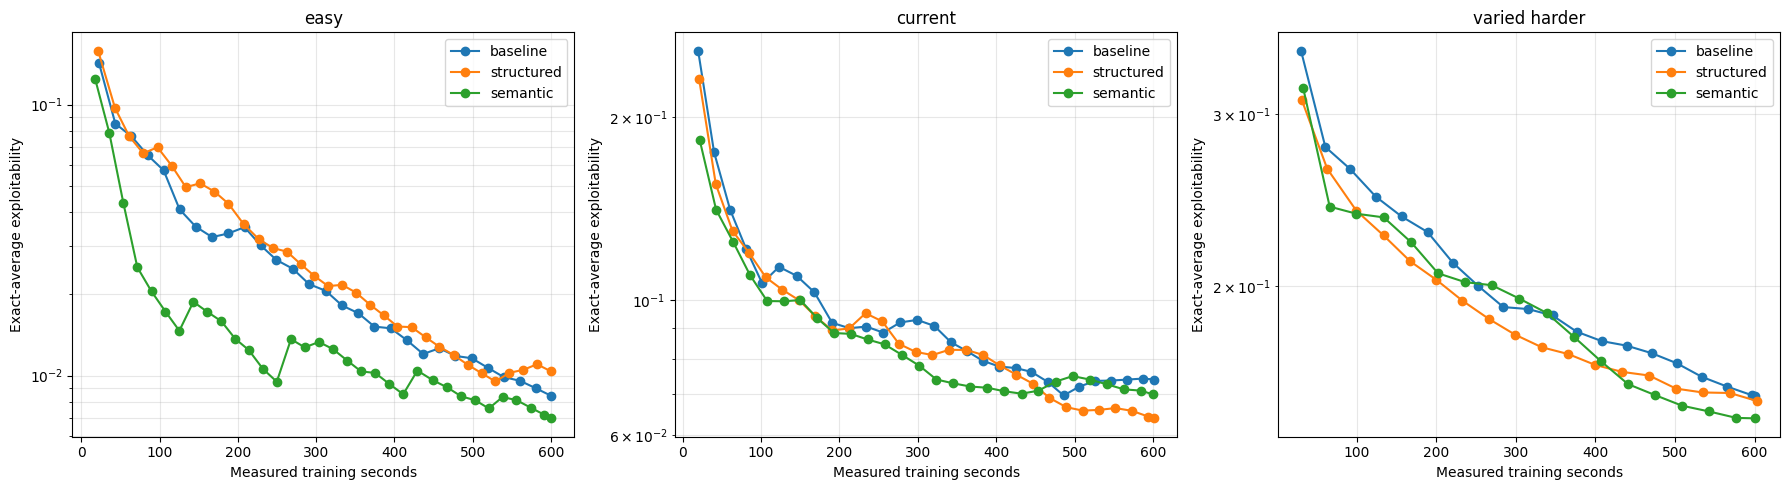

In [9]:
def evaluation_seconds(run):
    elapsed_by_iter = {
        record['iteration']: record['elapsed_s']
        for record in run['logs']['training_series']
    }
    return np.asarray([elapsed_by_iter[point['iter']] for point in run['logs']['exploitability_series']])


def exploitability_values(run, key):
    return np.asarray([2 * point[key] - 1 for point in run['logs']['exploitability_series']])


def validation_series(run, family, key):
    records = [record for record in run['logs']['training_series'] if 'validation' in record]
    x = np.asarray([record['elapsed_s'] for record in records])
    y = np.asarray([
        np.mean([player[key] for player in record['validation'][family] if key in player])
        for record in records
    ])
    return x, y


def normalized_auc(values, seconds):
    if len(values) < 2 or seconds[-1] == seconds[0]:
        return np.nan
    return float(np.trapezoid(values, seconds) / (seconds[-1] - seconds[0]))


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, spec_label in zip(axes, SPECS):
    for run in encoding_runs:
        if run['spec'] != spec_label:
            continue
        ax.plot(
            evaluation_seconds(run),
            exploitability_values(run, 'exact_average_predicted_avg'),
            marker='o',
            label=run['encoding'],
        )
    ax.set(title=spec_label, xlabel='Measured training seconds', ylabel='Exact-average exploitability', yscale='log')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
fig.tight_layout();


In [10]:
encoding_rows = []
for run in encoding_runs:
    exact = exploitability_values(run, 'exact_average_predicted_avg')
    learned = exploitability_values(run, 'predicted_avg')
    current = exploitability_values(run, 'current_predicted_avg')
    seconds = evaluation_seconds(run)
    _, mse = validation_series(run, 'advantage', 'mse')
    _, tv = validation_series(run, 'advantage', 'strategy_tv')
    training = run['logs']['training_series']
    encoding_rows.append({
        'spec': run['spec'],
        'encoding': run['encoding'],
        'input dimension': run['input_dim'],
        'parameters per network': run['parameters_per_network'],
        'iterations completed': run['iterations'],
        'final exact-average exploitability': exact[-1],
        'best exact-average exploitability': exact.min(),
        'exact-average normalized AUC': normalized_auc(exact, seconds),
        'final learned-average exploitability': learned[-1],
        'final learned-minus-exact gap': learned[-1] - exact[-1],
        'final current exploitability': current[-1],
        'final held-out advantage MSE': mse[-1],
        'final held-out strategy TV': tv[-1],
        'mean traversal s': np.mean([record['timing']['traversal_s'] for record in training]),
        'mean advantage fit s': np.mean([record['timing']['advantage_training_s'] for record in training]),
    })

encoding_summary = pd.DataFrame(encoding_rows).set_index(['spec', 'encoding']).sort_index()
display(encoding_summary.style.format(precision=6).background_gradient(
    subset=['final exact-average exploitability', 'exact-average normalized AUC'],
    cmap='RdYlGn_r',
))

encoding_aggregate = encoding_summary.groupby(level='encoding').agg({
    'final exact-average exploitability': 'mean',
    'exact-average normalized AUC': 'mean',
    'final held-out advantage MSE': 'mean',
    'final held-out strategy TV': 'mean',
})
encoding_aggregate.style.format(precision=6).background_gradient(cmap='RdYlGn_r')


,final exact-average exploitability,exact-average normalized AUC,final held-out advantage MSE,final held-out strategy TV
encoding,,,,
baseline,0.078885,0.109384,0.454168,0.301140
semantic,0.074380,0.098687,0.449964,0.291600
structured,0.075535,0.104642,0.454906,0.308879


## Select the encoding for Experiment 2

Set this after inspecting consistency across specs. The default below assumes the semantic encoding wins; change it if the results disagree.

In [12]:
chosen_encoder_label = 'baseline'
chosen_encoder_cls = ENCODERS[chosen_encoder_label]
replay_spec = SPECS['varied harder']

chosen_encoder_label, replay_spec.to_short_str()


('baseline', 'r4_s4_h3_hpt_ss')

## Experiment 2: replay and fitting schedule

Four schedules are compared on the current spec:

- `fixed 100 steps`: the existing rule.
- `fixed replay ratio=20`: optimizer examples processed track newly generated advantage records.
- `growing replay ratio`: ratio starts at 10 and grows by 0.15 per iteration to a cap of 40.
- `adaptive held-out`: train in 25-step chunks, stopping after held-out MSE fails to improve by 1% at two checks.

The summary reports realized replay ratios. After the first pass, adjust ratio 20 if it is badly mismatched with the baseline's observed ratio. Default total measured training time is 32 minutes: `4 schedules × 8 minutes`.

In [13]:
replay_training_seconds = 8 * 60
replay_seed = 27

REPLAY_CONFIGS = {
    'fixed 100 steps': {
        'replay_mode': 'fixed_steps',
        'advantage_train_steps': 100,
    },
    'fixed replay ratio=20': {
        'replay_mode': 'fixed_ratio',
        'replay_ratio': 20.0,
        'min_advantage_steps': 25,
        'max_advantage_steps': 800,
    },
    'growing replay ratio': {
        'replay_mode': 'growing_ratio',
        'growing_ratio_start': 10.0,
        'growing_ratio_increment': 0.15,
        'growing_ratio_max': 40.0,
        'min_advantage_steps': 25,
        'max_advantage_steps': 800,
    },
    'adaptive held-out': {
        'replay_mode': 'adaptive',
        'adaptive_chunk_steps': 25,
        'adaptive_min_steps': 50,
        'adaptive_max_steps': 500,
        'adaptive_patience': 2,
        'adaptive_min_relative_improvement': 0.01,
    },
}

replay_runs = []
for label, replay_config in REPLAY_CONFIGS.items():
    print(f'\n=== {label} ===')
    kwargs = {**COMMON_KWARGS, **replay_config}
    trainer = ExperimentalDeepCFRTrainer(
        replay_spec,
        encoder_cls=chosen_encoder_cls,
        positive_beta=0.5,
        seed=replay_seed,
        **kwargs,
    )
    exact_averager = ExactDenseStrategyAverager(replay_spec)
    _, logs, trainer = deep_cfr_timed_loop(
        replay_spec,
        training_seconds=replay_training_seconds,
        trainer=trainer,
        traversals_per_player=traversals_per_player,
        eval_every=eval_every,
        exact_averager=exact_averager,
        debug=True,
    )
    replay_runs.append({'schedule': label, 'iterations': trainer.iteration, 'logs': logs})
    del trainer, exact_averager
    gc.collect()



=== fixed 100 steps ===
[deep-cfr] iter=1 training_budget=2.10/480.00s traverse=0.51s fit=1.58s
[deep-cfr] iter=2 training_budget=6.09/480.00s traverse=2.49s fit=1.50s
[deep-cfr] iter=3 training_budget=9.60/480.00s traverse=2.10s fit=1.41s
[deep-cfr] iter=4 training_budget=12.44/480.00s traverse=1.62s fit=1.22s
[deep-cfr] iter=5 training_budget=15.72/480.00s traverse=1.73s fit=1.55s
[deep-cfr] iter=6 training_budget=18.65/480.00s traverse=1.56s fit=1.37s
[deep-cfr] iter=7 training_budget=21.70/480.00s traverse=1.62s fit=1.43s
[deep-cfr] iter=8 training_budget=24.84/480.00s traverse=1.72s fit=1.42s
[deep-cfr] iter=9 training_budget=28.04/480.00s traverse=1.77s fit=1.42s
[deep-cfr] iter=10 training_budget=31.18/480.00s traverse=1.75s fit=1.39s
[deep-cfr] iter=11 training_budget=34.19/480.00s traverse=1.62s fit=1.39s
[deep-cfr] iter=12 training_budget=37.13/480.00s traverse=1.54s fit=1.40s
[deep-cfr] iter=13 training_budget=40.21/480.00s traverse=1.70s fit=1.38s
[deep-cfr] iter=14 traini

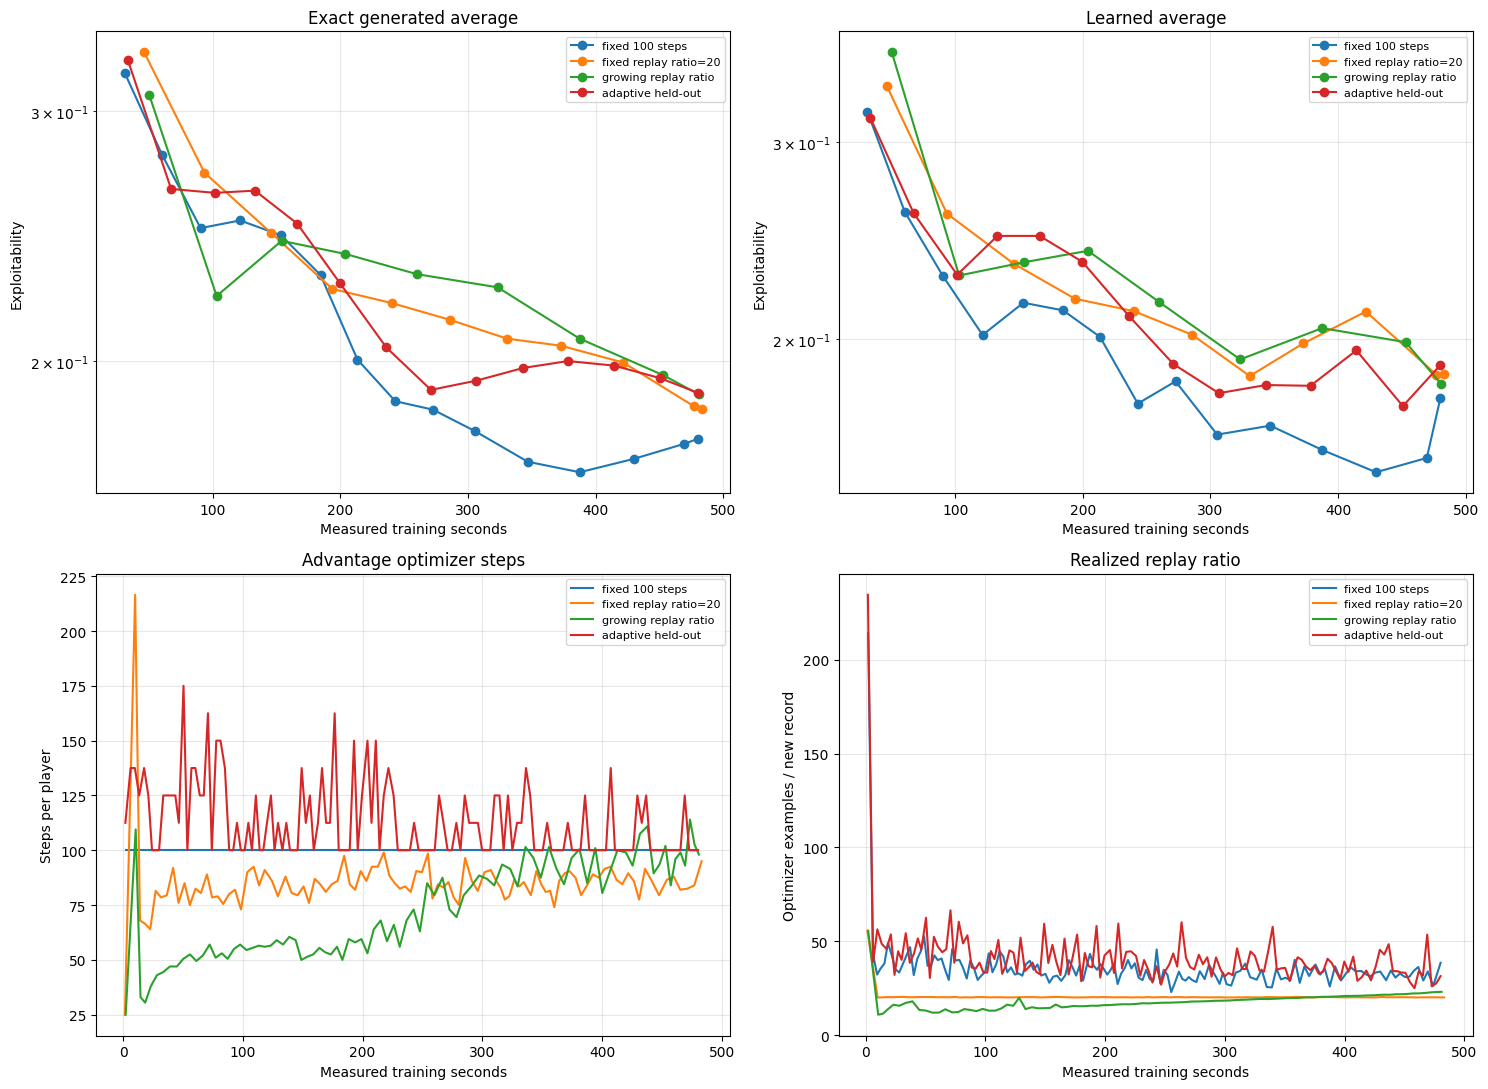

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for run in replay_runs:
    seconds = evaluation_seconds(run)
    axes[0, 0].plot(seconds, exploitability_values(run, 'exact_average_predicted_avg'), marker='o', label=run['schedule'])
    axes[0, 1].plot(seconds, exploitability_values(run, 'predicted_avg'), marker='o', label=run['schedule'])
    training_seconds_x = np.asarray([record['elapsed_s'] for record in run['logs']['training_series']])
    mean_steps = np.asarray([np.mean(record['advantage_steps_used']) for record in run['logs']['training_series']])
    mean_ratio = np.asarray([np.mean(record['realized_replay_ratio']) for record in run['logs']['training_series']])
    axes[1, 0].plot(training_seconds_x, mean_steps, label=run['schedule'])
    axes[1, 1].plot(training_seconds_x, mean_ratio, label=run['schedule'])

for ax, title, ylabel, log_y in zip(
    axes.flat,
    ('Exact generated average', 'Learned average', 'Advantage optimizer steps', 'Realized replay ratio'),
    ('Exploitability', 'Exploitability', 'Steps per player', 'Optimizer examples / new record'),
    (True, True, False, False),
):
    ax.set(title=title, xlabel='Measured training seconds', ylabel=ylabel)
    if log_y:
        ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout();


In [15]:
replay_rows = []
for run in replay_runs:
    exact = exploitability_values(run, 'exact_average_predicted_avg')
    learned = exploitability_values(run, 'predicted_avg')
    current = exploitability_values(run, 'current_predicted_avg')
    seconds = evaluation_seconds(run)
    _, mse = validation_series(run, 'advantage', 'mse')
    training = run['logs']['training_series']
    all_steps = np.asarray([np.mean(record['advantage_steps_used']) for record in training])
    all_ratios = np.asarray([np.mean(record['realized_replay_ratio']) for record in training])
    replay_rows.append({
        'schedule': run['schedule'],
        'iterations completed': run['iterations'],
        'final exact-average exploitability': exact[-1],
        'best exact-average exploitability': exact.min(),
        'exact-average normalized AUC': normalized_auc(exact, seconds),
        'final learned-average exploitability': learned[-1],
        'final learned-minus-exact gap': learned[-1] - exact[-1],
        'final current exploitability': current[-1],
        'final held-out advantage MSE': mse[-1],
        'median advantage steps per player': np.median(all_steps),
        'final advantage steps per player': all_steps[-1],
        'median realized replay ratio': np.median(all_ratios),
        'final realized replay ratio': all_ratios[-1],
        'mean traversal s': np.mean([record['timing']['traversal_s'] for record in training]),
        'mean advantage fit s': np.mean([record['timing']['advantage_training_s'] for record in training]),
        'mean strategy fit s': np.mean([record['timing']['strategy_training_s'] for record in training]),
    })

replay_summary = pd.DataFrame(replay_rows).set_index('schedule')
replay_summary.style.format(precision=6).background_gradient(
    subset=['final exact-average exploitability', 'best exact-average exploitability', 'exact-average normalized AUC'],
    cmap='RdYlGn_r',
)


,iterations completed,final exact-average exploitability,best exact-average exploitability,exact-average normalized AUC,final learned-average exploitability,final learned-minus-exact gap,final current exploitability,final held-out advantage MSE,median advantage steps per player,final advantage steps per player,median realized replay ratio,final realized replay ratio,mean traversal s,mean advantage fit s,mean strategy fit s
schedule,,,,,,,,,,,,,,,
fixed 100 steps,142,0.176436,0.167126,0.207488,0.177176,0.000740,0.392963,0.689323,100.000000,100.000000,33.924737,38.500513,1.840438,1.036759,0.504239
fixed replay ratio=20,101,0.185041,0.185041,0.226918,0.186146,0.001105,0.324078,0.642112,84.500000,95.000000,20.142563,20.068124,3.054897,1.117650,0.610462
growing replay ratio,87,0.189602,0.189602,0.227387,0.182367,-0.007235,0.351669,0.632865,66.000000,98.000000,17.162099,23.032370,3.688200,1.092832,0.747090
adaptive held-out,138,0.190092,0.190092,0.222960,0.189732,-0.000361,0.303241,0.684720,100.000000,100.000000,37.611214,31.396011,1.878033,1.151731,0.449547


## Reading the results

For encoding, prioritize consistency of exact-average exploitability and normalized AUC across all three specs. Lower held-out MSE without a better exact average is not sufficient.

For replay schedules, compare by measured training seconds. A useful schedule should improve exact-average AUC or endpoint without merely producing a temporarily better current policy. If adaptive fitting repeatedly hits its maximum, its stopping rule is not detecting convergence; if it stays near its minimum while underperforming, it is stopping too aggressively.

Target reparameterizations such as explicit per-record normalization, sign-plus-magnitude heads, and positive-support-plus-relative-weight heads are intentionally left for a separate experiment so that encoding and replay effects remain identifiable.

## Follow-up: deliberately increase advantage fitting

The first replay experiment unintentionally tested *less* fitting: fixed 100 steps naturally realized a replay ratio around 35–40, while the ratio-based schedules stayed near 20. This follow-up tests the original hypothesis directly by never allowing replay-based schedules below 100 advantage steps.

Compared schedules:

- `fixed 100 steps`: reference.
- `fixed 300 steps`: substantially more fitting regardless of generated data.
- `fixed replay ratio=40`: approximately matches or exceeds the reference replay ratio, with a 100-step floor.
- `growing replay ratio 30→80`: fitting effort rises over training, also with a 100-step floor.

The records-per-initial-traversal plot helps identify whether different current policies lead into systematically larger traverser subtrees.

In [16]:
increased_fitting_seconds = 8 * 60
increased_fitting_seed = 37

INCREASED_FITTING_CONFIGS = {
    'fixed 100 steps': {
        'replay_mode': 'fixed_steps',
        'advantage_train_steps': 100,
    },
    'fixed 300 steps': {
        'replay_mode': 'fixed_steps',
        'advantage_train_steps': 300,
    },
    'fixed replay ratio=40': {
        'replay_mode': 'fixed_ratio',
        'replay_ratio': 40.0,
        'min_advantage_steps': 100,
        'max_advantage_steps': 800,
    },
    'growing replay ratio 30→80': {
        'replay_mode': 'growing_ratio',
        'growing_ratio_start': 30.0,
        'growing_ratio_increment': 0.5,
        'growing_ratio_max': 80.0,
        'min_advantage_steps': 100,
        'max_advantage_steps': 800,
    },
}

increased_fitting_runs = []
for label, fitting_config in INCREASED_FITTING_CONFIGS.items():
    print(f'\n=== {label} ===')
    trainer = ExperimentalDeepCFRTrainer(
        replay_spec,
        encoder_cls=chosen_encoder_cls,
        positive_beta=0.5,
        seed=increased_fitting_seed,
        **{**COMMON_KWARGS, **fitting_config},
    )
    exact_averager = ExactDenseStrategyAverager(replay_spec)
    _, logs, trainer = deep_cfr_timed_loop(
        replay_spec,
        training_seconds=increased_fitting_seconds,
        trainer=trainer,
        traversals_per_player=traversals_per_player,
        eval_every=eval_every,
        exact_averager=exact_averager,
        debug=True,
    )
    increased_fitting_runs.append({
        'schedule': label,
        'iterations': trainer.iteration,
        'logs': logs,
    })
    del trainer, exact_averager
    gc.collect()



=== fixed 100 steps ===
[deep-cfr] iter=1 training_budget=2.25/480.00s traverse=0.49s fit=1.75s
[deep-cfr] iter=2 training_budget=7.07/480.00s traverse=3.36s fit=1.47s
[deep-cfr] iter=3 training_budget=10.68/480.00s traverse=2.12s fit=1.49s
[deep-cfr] iter=4 training_budget=14.00/480.00s traverse=1.91s fit=1.42s
[deep-cfr] iter=5 training_budget=17.63/480.00s traverse=2.21s fit=1.41s
[deep-cfr] iter=6 training_budget=21.28/480.00s traverse=2.17s fit=1.49s
[deep-cfr] iter=7 training_budget=24.96/480.00s traverse=2.22s fit=1.45s
[deep-cfr] iter=8 training_budget=28.56/480.00s traverse=2.13s fit=1.47s
[deep-cfr] iter=9 training_budget=32.10/480.00s traverse=2.07s fit=1.48s
[deep-cfr] iter=10 training_budget=35.43/480.00s traverse=1.91s fit=1.42s
[deep-cfr] iter=11 training_budget=38.83/480.00s traverse=1.90s fit=1.50s
[deep-cfr] iter=12 training_budget=42.52/480.00s traverse=2.16s fit=1.53s
[deep-cfr] iter=13 training_budget=46.17/480.00s traverse=2.23s fit=1.42s
[deep-cfr] iter=14 train

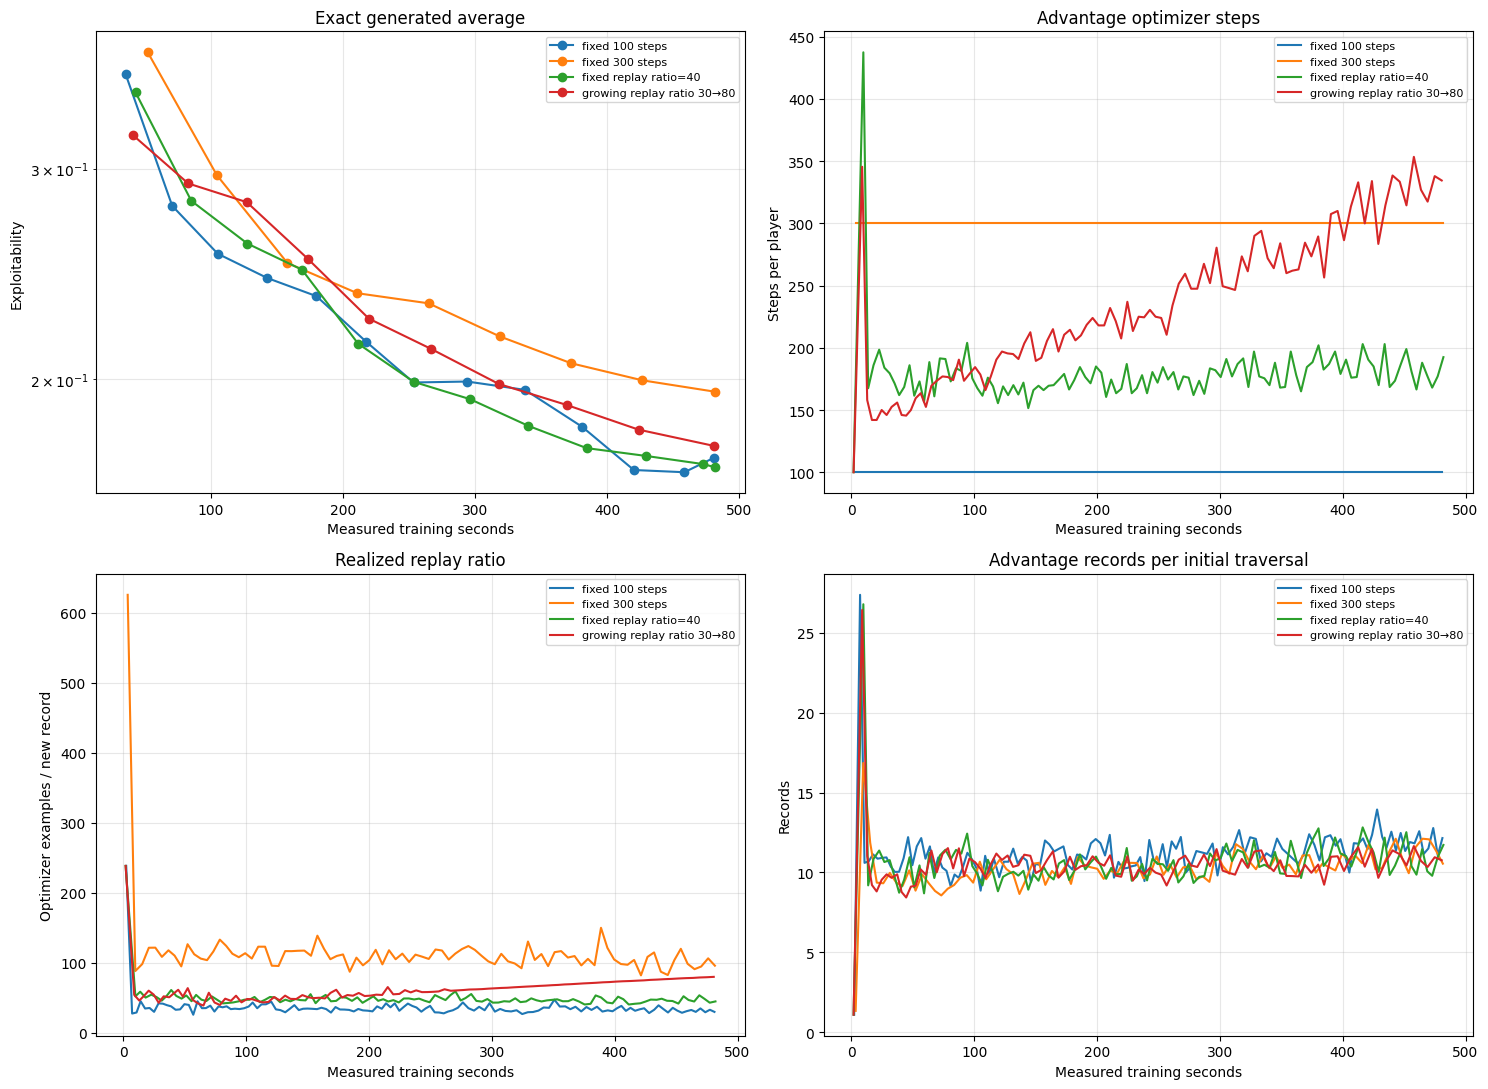

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for run in increased_fitting_runs:
    training = run['logs']['training_series']
    eval_seconds = evaluation_seconds(run)
    training_seconds_x = np.asarray([record['elapsed_s'] for record in training])
    mean_steps = np.asarray([np.mean(record['advantage_steps_used']) for record in training])
    mean_ratio = np.asarray([np.mean(record['realized_replay_ratio']) for record in training])
    advantage_records_per_initial_traversal = np.asarray([
        sum(record['new_advantage_records']) / (2 * traversals_per_player)
        for record in training
    ])

    axes[0, 0].plot(eval_seconds, exploitability_values(run, 'exact_average_predicted_avg'), marker='o', label=run['schedule'])
    axes[0, 1].plot(training_seconds_x, mean_steps, label=run['schedule'])
    axes[1, 0].plot(training_seconds_x, mean_ratio, label=run['schedule'])
    axes[1, 1].plot(training_seconds_x, advantage_records_per_initial_traversal, label=run['schedule'])

for ax, title, ylabel, log_y in zip(
    axes.flat,
    ('Exact generated average', 'Advantage optimizer steps', 'Realized replay ratio', 'Advantage records per initial traversal'),
    ('Exploitability', 'Steps per player', 'Optimizer examples / new record', 'Records'),
    (True, False, False, False),
):
    ax.set(title=title, xlabel='Measured training seconds', ylabel=ylabel)
    if log_y:
        ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout();


In [18]:
increased_fitting_rows = []
for run in increased_fitting_runs:
    exact = exploitability_values(run, 'exact_average_predicted_avg')
    learned = exploitability_values(run, 'predicted_avg')
    current = exploitability_values(run, 'current_predicted_avg')
    seconds = evaluation_seconds(run)
    _, mse = validation_series(run, 'advantage', 'mse')
    training = run['logs']['training_series']
    all_steps = np.asarray([np.mean(record['advantage_steps_used']) for record in training])
    all_ratios = np.asarray([np.mean(record['realized_replay_ratio']) for record in training])
    records_per_initial_traversal = np.asarray([
        sum(record['new_advantage_records']) / (2 * traversals_per_player)
        for record in training
    ])
    increased_fitting_rows.append({
        'schedule': run['schedule'],
        'iterations completed': run['iterations'],
        'final exact-average exploitability': exact[-1],
        'best exact-average exploitability': exact.min(),
        'exact-average normalized AUC': normalized_auc(exact, seconds),
        'final learned-average exploitability': learned[-1],
        'final learned-minus-exact gap': learned[-1] - exact[-1],
        'final current exploitability': current[-1],
        'final held-out advantage MSE': mse[-1],
        'median advantage steps per player': np.median(all_steps),
        'final advantage steps per player': all_steps[-1],
        'median realized replay ratio': np.median(all_ratios),
        'final realized replay ratio': all_ratios[-1],
        'mean advantage records per initial traversal': records_per_initial_traversal.mean(),
        'final advantage records per initial traversal': records_per_initial_traversal[-1],
        'mean traversal s': np.mean([record['timing']['traversal_s'] for record in training]),
        'mean advantage fit s': np.mean([record['timing']['advantage_training_s'] for record in training]),
        'mean strategy fit s': np.mean([record['timing']['strategy_training_s'] for record in training]),
    })

increased_fitting_summary = pd.DataFrame(increased_fitting_rows).set_index('schedule')
increased_fitting_summary.style.format(precision=6).background_gradient(
    subset=['final exact-average exploitability', 'best exact-average exploitability', 'exact-average normalized AUC'],
    cmap='RdYlGn_r',
)


,iterations completed,final exact-average exploitability,best exact-average exploitability,exact-average normalized AUC,final learned-average exploitability,final learned-minus-exact gap,final current exploitability,final held-out advantage MSE,median advantage steps per player,final advantage steps per player,median realized replay ratio,final realized replay ratio,mean advantage records per initial traversal,final advantage records per initial traversal,mean traversal s,mean advantage fit s,mean strategy fit s
schedule,,,,,,,,,,,,,,,,,
fixed 100 steps,126,0.171985,0.167201,0.216751,0.160723,-0.011262,0.344455,0.674955,100.000000,100.000000,33.757851,29.481794,11.180794,12.150000,2.341258,1.014963,0.462682
fixed 300 steps,90,0.195248,0.195248,0.239766,0.190692,-0.004556,0.299461,0.653502,300.000000,300.000000,108.347933,95.569710,10.243444,10.550000,2.056353,2.838433,0.455869
fixed replay ratio=40,112,0.168772,0.168772,0.216541,0.173901,0.005130,0.309956,0.645757,176.000000,192.500000,46.740413,44.471437,10.575536,11.720000,2.136922,1.711752,0.454951
growing replay ratio 30→80,100,0.175920,0.175920,0.227252,0.174494,-0.001426,0.287494,0.681443,224.000000,334.500000,59.216191,79.577695,10.451800,10.760000,2.150060,2.199229,0.456916


### Follow-up interpretation

This experiment answers whether spending more measured training time on advantage fitting improves the generated average enough to offset completing fewer CFR iterations.

- If `fixed 300` or the increasing ratio wins by exact-average AUC and endpoint, fitting was still underallocated.
- If `fixed 100` remains strongest, additional fitting is not currently the highest-value use of clock time.
- If replay-based schedules change records per traversal substantially, part of their runtime effect comes through policy-dependent game-tree exploration rather than optimizer cost alone.